# Backtest Walkthrough: Corn Futures Weather Signal

A step-by-step breakdown of the precipitation-based corn futures trading strategy,
covering signal generation, position management, and P&L attribution.

- **Period**: January 2 -- February 28, 2025 (~40 trading days)
- **Allocation**: $100,000,000
- **Data**: Corn futures (OHLCV) and Corn Belt daily precipitation (Iowa, Illinois, Nebraska)

### A note on corn futures pricing

Corn futures on the Chicago Board of Trade (CBOT) are quoted in **cents per bushel**.
A quote of 459.50 means $4.595 per bushel. One standard contract covers 5,000 bushels,
so the notional value of one contract at 459.50 is $22,975. A 1-cent move in the
quote equals a $50 change in contract value (5,000 bushels x $0.01).

Throughout this notebook, raw prices and per-unit P&L are in cents/bushel (the
exchange convention). All P&L figures that matter -- daily, cumulative, drawdown --
are converted to **dollars** using the $100M allocation and the resulting contract
count.

## Hypothesis

Corn Belt precipitation is a leading indicator of corn futures prices. The logic:

**Buy (long)**: When the 30-day rolling average Corn Belt precipitation reaches or
exceeds the 75th percentile of its historical distribution, heavy rainfall is likely
damaging crops or delaying planting. Reduced supply expectations push futures prices
higher.

**Sell (short)**: When rolling precipitation falls to or below the 25th percentile,
dry but non-extreme conditions suggest normal crop yields and ample supply. Futures
prices tend to remain flat or decline without a supply shock.

**Flat (no position)**: When precipitation is between the 25th and 75th percentiles,
the signal is ambiguous. We hold no position and wait for a clearer signal.

Thresholds are calibrated on historical data ending 2024-03-10 to prevent lookahead
bias. The signal is lagged by one day to reflect realistic execution timing.

In [1]:
import logging
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

from signal_gen import (
    load_futures, load_weather, merge_on_trading_days,
    add_avg_precip, add_rolling_precip_lag, generate_signal,
    ROLLING_WINDOW, LAG_DAYS,
)
from backtest import compute_positions, compute_daily_pnl, build_trade_log, compute_stats

logging.basicConfig(
    level=logging.INFO, stream=sys.stdout,
    format="%(asctime)s %(name)s %(levelname)s %(message)s",
)
logger = logging.getLogger("backtest_walkthrough")

ALLOCATION_USD = 100_000_000
BUSHELS_PER_CONTRACT = 5_000
DOLLAR_PER_CENT_PER_CONTRACT = 50
WINDOW_START = "2025-01-02"
WINDOW_END = "2025-02-28"
TRAIN_END = "2024-03-10"

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
VISUALS_DIR = Path("backtest_visuals")
VISUALS_DIR.mkdir(exist_ok=True)


def save_fig(fig, filename):
    """Save a matplotlib figure to the backtest_visuals directory.

    Args:
        fig: Matplotlib figure object.
        filename: Output filename (e.g., '01_threshold_calibration.png').
    """
    path = VISUALS_DIR / filename
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    logger.info("Saved figure: %s", path)

In [3]:
futures = load_futures()
weather = load_weather()
df_full = merge_on_trading_days(futures, weather)
df_full = add_avg_precip(df_full)
df_full = add_rolling_precip_lag(df_full, window=ROLLING_WINDOW, lag=LAG_DAYS)

rolling_train = df_full.loc[:TRAIN_END, "rolling_precip"].dropna()
threshold_long = rolling_train.quantile(0.75)
threshold_short = rolling_train.quantile(0.25)
logger.info("Thresholds -- long: %.2f, short: %.2f", threshold_long, threshold_short)

df_full = generate_signal(df_full, threshold_long, threshold_short)
df = df_full.loc[WINDOW_START:WINDOW_END].copy()
logger.info(
    "Window: %s to %s (%d trading days)",
    df.index[0].date(), df.index[-1].date(), len(df),
)
df.head()

2026-03-11 00:01:48,796 signal_gen INFO Loaded futures: 3810 rows (2010-01-11 to 2025-03-07)
2026-03-11 00:01:48,805 signal_gen INFO Loaded weather: 5538 rows (2010-01-11 to 2025-03-10)
2026-03-11 00:01:48,812 signal_gen INFO Merged dataset: 3810 rows
2026-03-11 00:01:48,825 backtest_walkthrough INFO Thresholds -- long: 3.82, short: 1.70
2026-03-11 00:01:48,827 signal_gen INFO Signal distribution: long=25.7% short=25.2% flat=49.1%
2026-03-11 00:01:48,828 backtest_walkthrough INFO Window: 2025-01-02 to 2025-02-28 (40 trading days)


,Close,High,Low,Open,Volume,Iowa_temp_max_f,Iowa_temp_min_f,Iowa_precip_in,Illinois_temp_max_f,Illinois_temp_min_f,Illinois_precip_in,Nebraska_temp_max_f,Nebraska_temp_min_f,Nebraska_precip_in,avg_precip_in,rolling_precip,signal
2025-01-02,459.50,459.75,456.25,457.25,163449,28.40,19.76,0.090551,42.26,26.24,0.031496,35.06,23.54,0.043307,0.055118,1.875328,0
2025-01-03,450.75,459.75,449.25,459.50,199340,22.64,11.48,0.000000,31.64,20.84,0.000000,29.12,21.20,0.000000,0.000000,1.095801,-1
2025-01-06,457.75,460.25,451.50,451.50,227403,17.96,8.78,0.000000,26.42,19.76,0.066929,16.88,5.18,0.000000,0.022310,1.073491,-1
2025-01-07,458.00,458.50,453.00,456.00,211629,22.28,7.88,0.000000,23.18,13.28,0.000000,23.54,10.22,0.000000,0.000000,1.073491,-1
2025-01-08,454.00,459.25,453.50,457.75,192588,22.46,5.72,0.000000,21.02,11.48,0.000000,21.02,5.36,0.000000,0.000000,1.073491,-1


## Part 3: Threshold Calibration

The signal thresholds are calibrated on the **training period** (all data before
2024-03-10). This ensures no information from the test window leaks into the signal
design.

The histogram below shows the distribution of 30-day rolling precipitation sums
across all training-period trading days. The green line marks the 75th percentile
(long threshold) and the red line marks the 25th percentile (short threshold).

2026-03-11 00:01:48,996 backtest_walkthrough INFO Saved figure: backtest_visuals/01_threshold_calibration.png


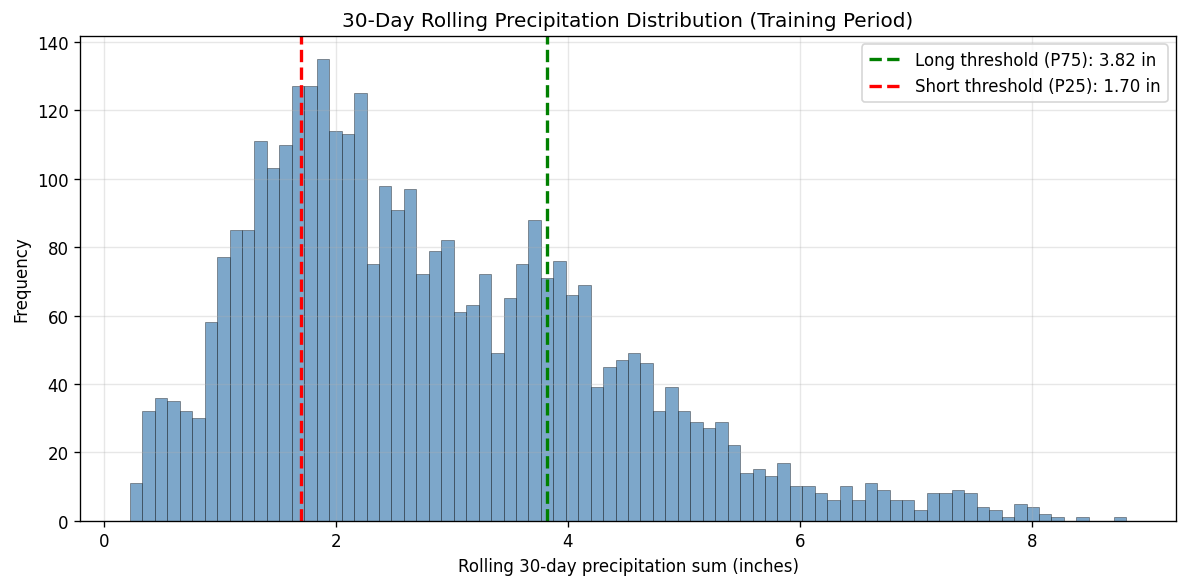

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    rolling_train, bins=80, edgecolor="black", linewidth=0.3,
    color="steelblue", alpha=0.7,
)
ax.axvline(
    threshold_long, color="green", linestyle="--", linewidth=2,
    label=f"Long threshold (P75): {threshold_long:.2f} in",
)
ax.axvline(
    threshold_short, color="red", linestyle="--", linewidth=2,
    label=f"Short threshold (P25): {threshold_short:.2f} in",
)
ax.set_title("30-Day Rolling Precipitation Distribution (Training Period)")
ax.set_xlabel("Rolling 30-day precipitation sum (inches)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
save_fig(fig, "01_threshold_calibration.png")
plt.show()

## Part 4: Signal Generation

The signal is generated by comparing each day's rolling precipitation to the
calibrated thresholds:

| Condition | Signal | Interpretation |
|-----------|--------|----------------|
| rolling_precip >= threshold_long | +1 (long) | Heavy rain, bullish supply shock |
| rolling_precip <= threshold_short | -1 (short) | Low precip, normal supply |
| Between thresholds | 0 (flat) | Ambiguous, no position |

The table below shows the first 10 trading days of the window with the close price,
rolling precipitation, and generated signal.

In [5]:
df[["Close", "rolling_precip", "signal"]].head(10)

,Close,rolling_precip,signal
2025-01-02,459.50,1.875328,0
2025-01-03,450.75,1.095801,-1
2025-01-06,457.75,1.073491,-1
2025-01-07,458.00,1.073491,-1
2025-01-08,454.00,1.073491,-1
2025-01-09,456.00,1.073491,-1
2025-01-10,470.50,1.044619,-1
2025-01-13,476.50,1.146982,-1
2025-01-14,474.50,1.095801,-1
2025-01-15,478.75,1.102362,-1


## Part 5: Position and Execution Delay

A signal generated at the close of day T cannot be acted upon until day T+1.
The `position` column reflects this one-day lag:

```
position[T] = signal[T-1]
```

This prevents lookahead bias: we only trade on information that was available
before the market opened.

The table below compares the raw signal with the lagged position for the first
10 days.

In [6]:
df = compute_positions(df)
df[["Close", "signal", "position"]].head(10)

,Close,signal,position
2025-01-02,459.50,0,0
2025-01-03,450.75,-1,0
2025-01-06,457.75,-1,-1
2025-01-07,458.00,-1,-1
2025-01-08,454.00,-1,-1
2025-01-09,456.00,-1,-1
2025-01-10,470.50,-1,-1
2025-01-13,476.50,-1,-1
2025-01-14,474.50,-1,-1
2025-01-15,478.75,-1,-1


### Terminology

In futures trading, you do not need to own something before you can sell it.
The two directions are:

- **Long** (signal = +1): Enter a position that profits when the price goes **up**.
  This is the equivalent of "buying" in stock trading.
- **Short** (signal = -1): Enter a position that profits when the price goes **down**.
  You are borrowing and selling a contract you don't own, betting the price will fall.
  There is no prior purchase required.
- **Flat** (signal = 0): No position. You are not exposed to price moves in either
  direction.

The **action** on any given day depends on the transition from the previous position
to the current one:

| Previous Position | Current Position | Action |
|-------------------|-----------------|--------|
| Flat | Long | **Enter long** -- open a new long position |
| Flat | Short | **Enter short** -- open a new short position |
| Long | Flat | **Exit long** -- close the long position |
| Short | Flat | **Exit short** (cover) -- close the short position |
| Long | Short | **Reverse to short** -- close long, open short |
| Short | Long | **Reverse to long** -- close short, open long |
| Same | Same | **Hold** -- no change |

### Daily Decision Log

Every trading day with the close price, what action was taken, and why. The
"Reasoning" column shows the rolling precipitation value relative to the thresholds
and explains the resulting decision.

2026-03-11 00:01:49,646 backtest_walkthrough INFO Saved figure: backtest_visuals/08_daily_decision_log.png


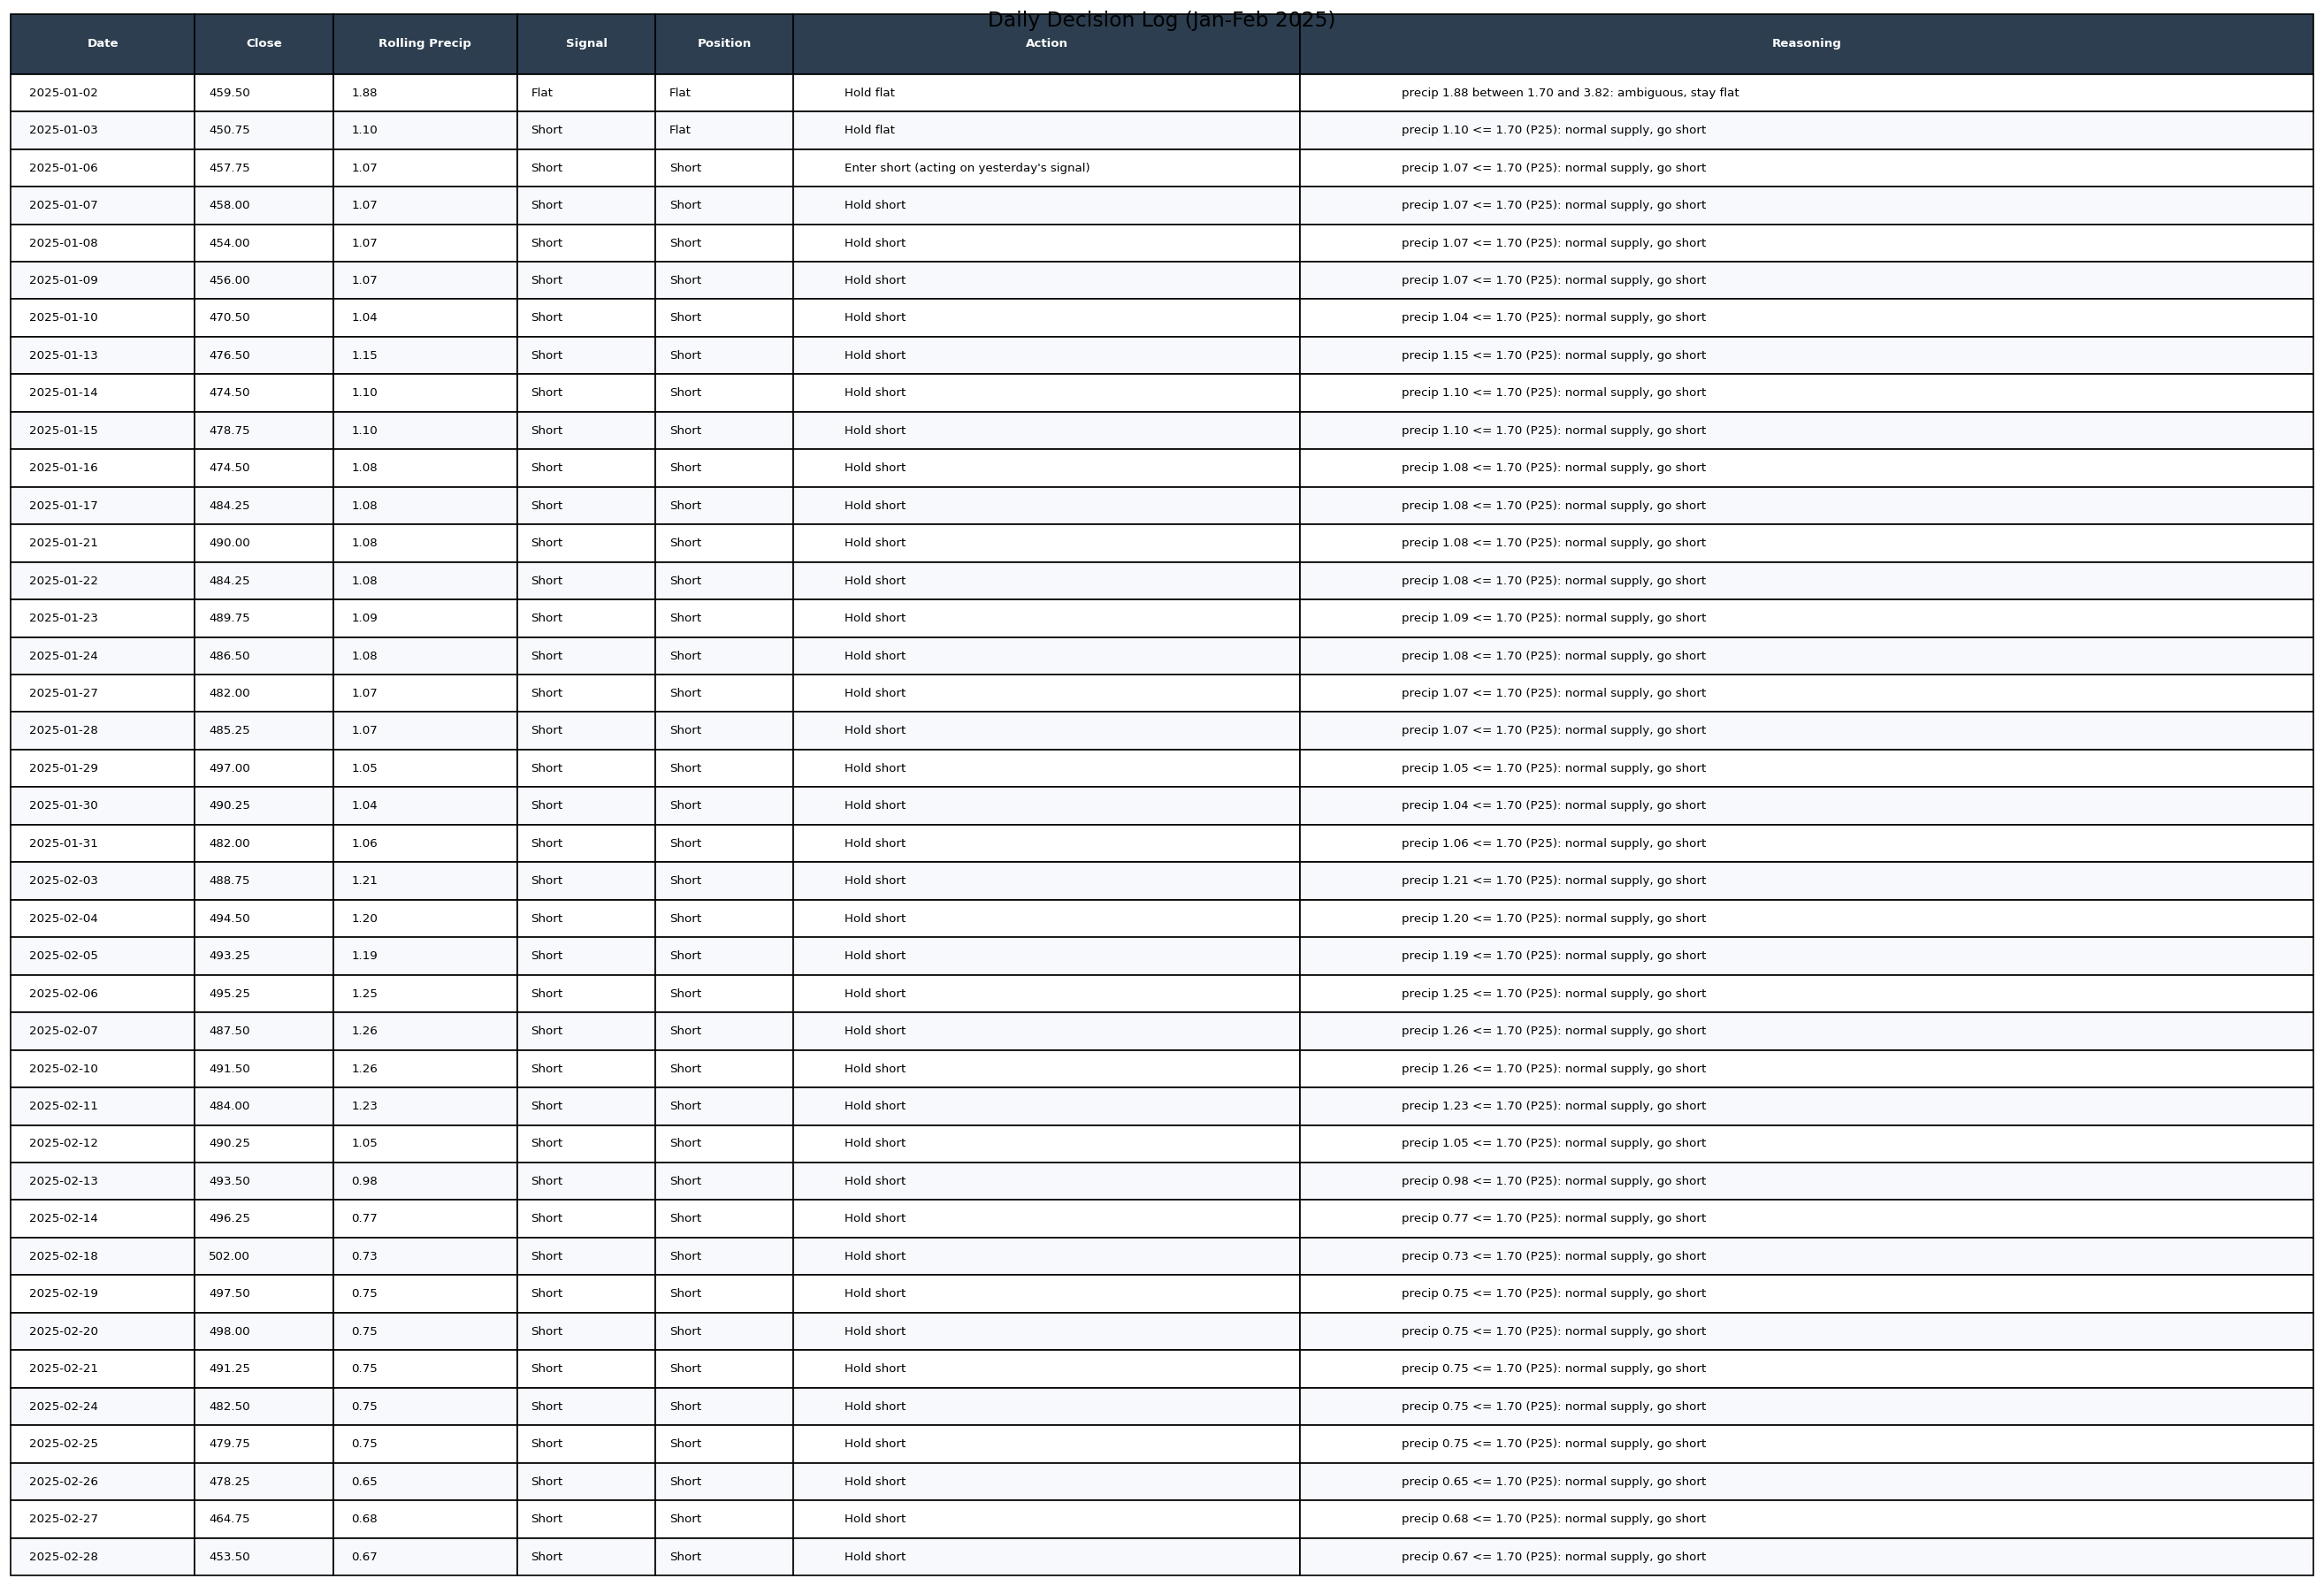

,Date,Close,Rolling Precip,Signal,Position,Action,Reasoning
0,2025-01-02,459.50,1.88,Flat,Flat,Hold flat,"precip 1.88 between 1.70 and 3.82: ambiguous, stay flat"
1,2025-01-03,450.75,1.10,Short,Flat,Hold flat,"precip 1.10 <= 1.70 (P25): normal supply, go short"
2,2025-01-06,457.75,1.07,Short,Short,Enter short (acting on yesterday's signal),"precip 1.07 <= 1.70 (P25): normal supply, go short"
3,2025-01-07,458.00,1.07,Short,Short,Hold short,"precip 1.07 <= 1.70 (P25): normal supply, go short"
4,2025-01-08,454.00,1.07,Short,Short,Hold short,"precip 1.07 <= 1.70 (P25): normal supply, go short"
5,2025-01-09,456.00,1.07,Short,Short,Hold short,"precip 1.07 <= 1.70 (P25): normal supply, go short"
6,2025-01-10,470.50,1.04,Short,Short,Hold short,"precip 1.04 <= 1.70 (P25): normal supply, go short"
7,2025-01-13,476.50,1.15,Short,Short,Hold short,"precip 1.15 <= 1.70 (P25): normal supply, go short"
8,2025-01-14,474.50,1.10,Short,Short,Hold short,"precip 1.10 <= 1.70 (P25): normal supply, go short"
9,2025-01-15,478.75,1.10,Short,Short,Hold short,"precip 1.10 <= 1.70 (P25): normal supply, go short"


In [7]:
ACTION_LABELS = {
    (0, 0): "Hold flat",
    (0, 1): "Enter long",
    (0, -1): "Enter short",
    (1, 0): "Exit long",
    (1, 1): "Hold long",
    (1, -1): "Reverse to short",
    (-1, 0): "Exit short",
    (-1, 1): "Reverse to long",
    (-1, -1): "Hold short",
}


def describe_signal(rolling_precip, signal, threshold_long, threshold_short):
    """Build a plain-language reason for the signal value.

    Args:
        rolling_precip: 30-day rolling precipitation sum.
        signal: Signal value (+1, -1, or 0).
        threshold_long: Long threshold value.
        threshold_short: Short threshold value.

    Returns:
        Human-readable string explaining the signal.
    """
    if pd.isna(rolling_precip):
        return "Insufficient data for rolling window"
    precip_str = f"precip {rolling_precip:.2f}"
    if signal == 1:
        return f"{precip_str} >= {threshold_long:.2f} (P75): low supply expected, go long"
    elif signal == -1:
        return f"{precip_str} <= {threshold_short:.2f} (P25): normal supply, go short"
    else:
        return f"{precip_str} between {threshold_short:.2f} and {threshold_long:.2f}: ambiguous, stay flat"


rows = []
prev_pos = 0
for date, row in df.iterrows():
    pos = int(row["position"])
    sig = int(row["signal"])
    action = ACTION_LABELS.get((prev_pos, pos), "Unknown")
    reason = describe_signal(row["rolling_precip"], sig, threshold_long, threshold_short)

    if prev_pos != pos:
        action_note = f"{action} (acting on yesterday's signal)"
    else:
        action_note = action

    rows.append({
        "Date": date.date(),
        "Close": f"{row['Close']:.2f}",
        "Rolling Precip": f"{row['rolling_precip']:.2f}",
        "Signal": {1: "Long", -1: "Short", 0: "Flat"}.get(sig, str(sig)),
        "Position": {1: "Long", -1: "Short", 0: "Flat"}.get(pos, str(pos)),
        "Action": action_note,
        "Reasoning": reason,
    })
    prev_pos = pos

decision_log = pd.DataFrame(rows)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 80)

# -- Render as PNG table --
n_rows = len(decision_log)
fig_height = 1.0 + n_rows * 0.35
fig, ax = plt.subplots(figsize=(22, fig_height))
ax.axis("off")
ax.set_title("Daily Decision Log (Jan-Feb 2025)", fontsize=14, pad=12)

col_widths = [0.08, 0.06, 0.08, 0.06, 0.06, 0.22, 0.44]
tbl = ax.table(
    cellText=decision_log.values,
    colLabels=decision_log.columns,
    cellLoc="left",
    colWidths=col_widths,
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)

# Style header row
for col_idx in range(len(decision_log.columns)):
    cell = tbl[0, col_idx]
    cell.set_facecolor("#2c3e50")
    cell.set_text_props(color="white", fontweight="bold")
    cell.set_height(0.04)

# Style data rows with alternating colors
for row_idx in range(1, n_rows + 1):
    bg = "#f7f9fc" if row_idx % 2 == 0 else "white"
    for col_idx in range(len(decision_log.columns)):
        cell = tbl[row_idx, col_idx]
        cell.set_facecolor(bg)
        cell.set_height(0.025)

plt.tight_layout()
save_fig(fig, "08_daily_decision_log.png")
plt.show()

decision_log

## Part 6: Visualizations

### Price Chart with Buy/Sell Signals

Triangle markers show the signal direction on each day. Shaded regions indicate
the actual held position (which lags the signal by one day).

2026-03-11 00:01:50,251 backtest_walkthrough INFO Saved figure: backtest_visuals/02_price_with_signals.png


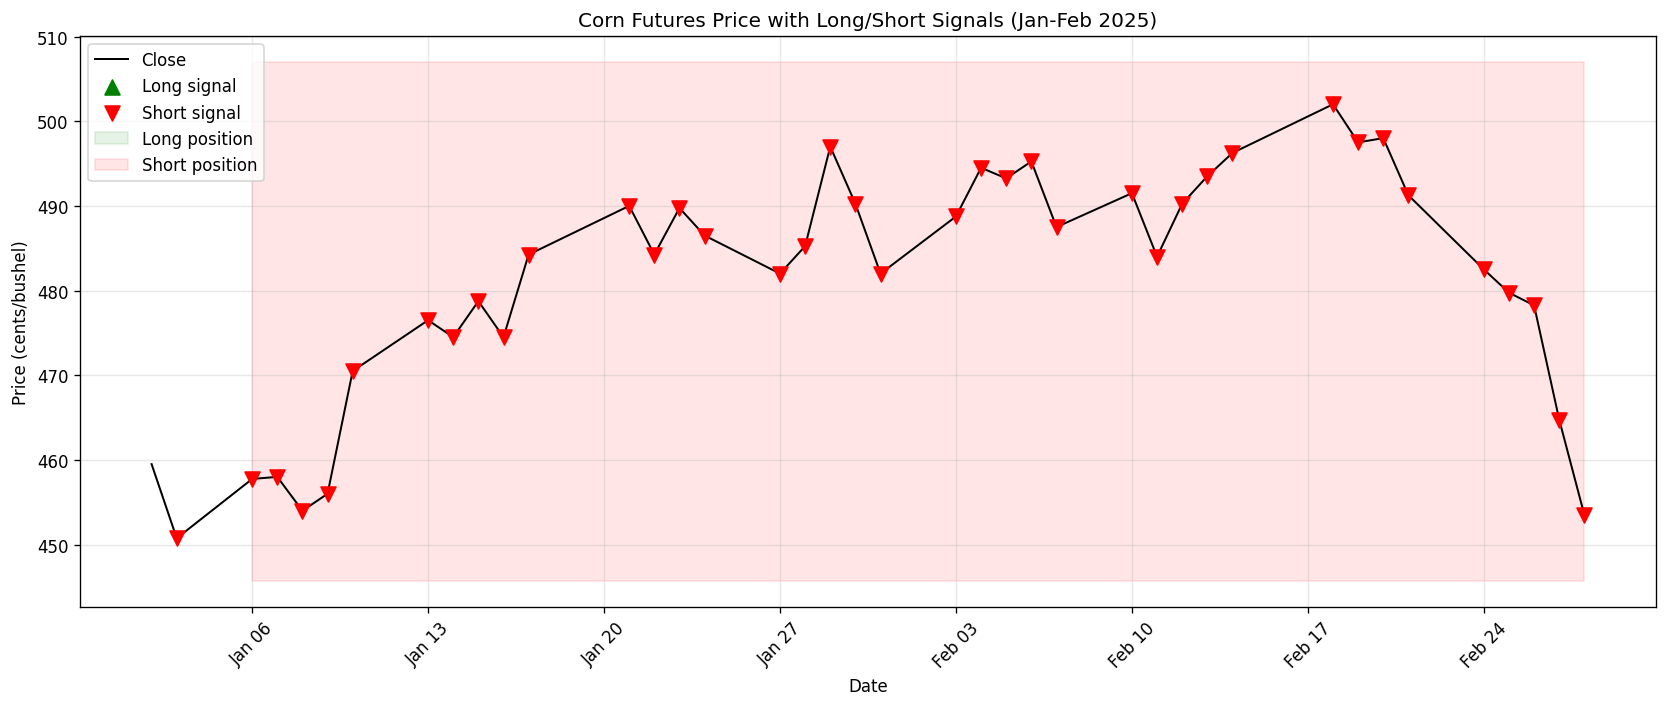

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df["Close"], linewidth=1.2, color="black", label="Close")

long_days = df[df["signal"] == 1]
short_days = df[df["signal"] == -1]
ax.scatter(
    long_days.index, long_days["Close"], marker="^", color="green",
    s=80, zorder=5, label="Long signal",
)
ax.scatter(
    short_days.index, short_days["Close"], marker="v", color="red",
    s=80, zorder=5, label="Short signal",
)

long_pos = df["position"] == 1
short_pos = df["position"] == -1
ymin, ymax = df["Close"].min() - 5, df["Close"].max() + 5
ax.fill_between(
    df.index, ymin, ymax, where=long_pos,
    alpha=0.1, color="green", label="Long position",
)
ax.fill_between(
    df.index, ymin, ymax, where=short_pos,
    alpha=0.1, color="red", label="Short position",
)

ax.set_title("Corn Futures Price with Long/Short Signals (Jan-Feb 2025)")
ax.set_ylabel("Price (cents/bushel)")
ax.set_xlabel("Date")
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
save_fig(fig, "02_price_with_signals.png")
plt.show()

## Part 7: Dollar P&L Conversion

The backtest engine computes P&L in **cents/bushel** -- the raw price change times
the position direction. This is a per-unit figure, like saying "the stock moved $2."
It does not tell you how much money you made or lost.

To get actual dollar P&L, we need to know **how many contracts** we are trading:

1. **Contract count**: `floor($100M / (price_cents / 100 * 5,000 bushels))` -- how
   many contracts fit in the allocation at the entry price.
2. **Dollar P&L per day**: `pnl_cents * num_contracts * $50/cent/contract` -- each
   cent of price movement is worth $50 per contract.
3. **Cumulative P&L**: running sum of daily dollar P&L.

The contract count is fixed at the period start (first close price) rather than
dynamically resized. This is simpler and more conservative.

In [9]:
df = compute_daily_pnl(df, cost_per_trade=0.0)

entry_price_cents = df["Close"].iloc[0]
contract_value_usd = (entry_price_cents / 100) * BUSHELS_PER_CONTRACT
num_contracts = math.floor(ALLOCATION_USD / contract_value_usd)

logger.info(
    "Entry price: %.2f cents/bushel ($%.2f/bushel)",
    entry_price_cents, entry_price_cents / 100,
)
logger.info("Contract value: $%s", f"{contract_value_usd:,.0f}")
logger.info("Number of contracts: %d", num_contracts)

2026-03-11 00:01:50,358 backtest_walkthrough INFO Entry price: 459.50 cents/bushel ($4.59/bushel)
2026-03-11 00:01:50,359 backtest_walkthrough INFO Contract value: $22,975
2026-03-11 00:01:50,359 backtest_walkthrough INFO Number of contracts: 4352


In [10]:
df["daily_pnl_usd"] = df["net_daily_pnl"] * num_contracts * DOLLAR_PER_CENT_PER_CONTRACT
df["cumulative_pnl_usd"] = df["daily_pnl_usd"].cumsum()

df[["Close", "position", "net_daily_pnl", "daily_pnl_usd", "cumulative_pnl_usd"]].tail(10)

,Close,position,net_daily_pnl,daily_pnl_usd,cumulative_pnl_usd
2025-02-14,496.25,-1,-2.75,-598400.0,-9900800.0
2025-02-18,502.00,-1,-5.75,-1251200.0,-11152000.0
2025-02-19,497.50,-1,4.50,979200.0,-10172800.0
2025-02-20,498.00,-1,-0.50,-108800.0,-10281600.0
2025-02-21,491.25,-1,6.75,1468800.0,-8812800.0
2025-02-24,482.50,-1,8.75,1904000.0,-6908800.0
2025-02-25,479.75,-1,2.75,598400.0,-6310400.0
2025-02-26,478.25,-1,1.50,326400.0,-5984000.0
2025-02-27,464.75,-1,13.50,2937600.0,-3046400.0
2025-02-28,453.50,-1,11.25,2448000.0,-598400.0


### Cumulative P&L

Dual-axis chart showing cumulative P&L in both cents/bushel (left axis) and
millions of dollars (right axis).

2026-03-11 00:01:50,509 backtest_walkthrough INFO Saved figure: backtest_visuals/03_cumulative_pnl.png


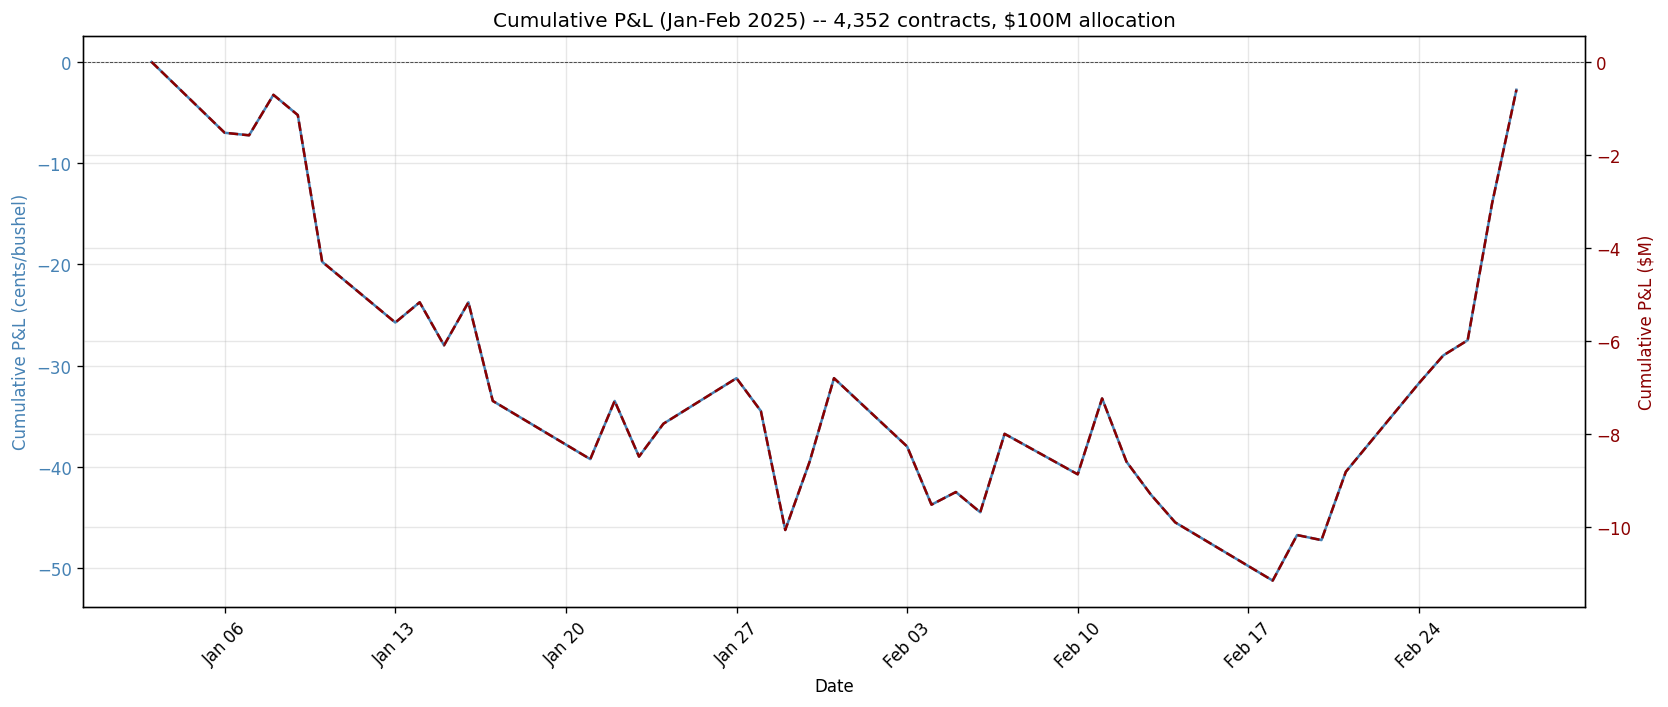

In [11]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color_cents = "steelblue"
ax1.plot(df.index, df["cumulative_pnl"], linewidth=1.5, color=color_cents)
ax1.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax1.set_ylabel("Cumulative P&L (cents/bushel)", color=color_cents)
ax1.tick_params(axis="y", labelcolor=color_cents)
ax1.set_xlabel("Date")
ax1.set_title(
    f"Cumulative P&L (Jan-Feb 2025) -- "
    f"{num_contracts:,} contracts, ${ALLOCATION_USD / 1e6:.0f}M allocation"
)
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

ax2 = ax1.twinx()
color_usd = "darkred"
ax2.plot(
    df.index, df["cumulative_pnl_usd"] / 1e6, linewidth=1.5,
    color=color_usd, linestyle="--",
)
ax2.set_ylabel("Cumulative P&L ($M)", color=color_usd)
ax2.tick_params(axis="y", labelcolor=color_usd)

plt.tight_layout()
save_fig(fig, "03_cumulative_pnl.png")
plt.show()

### Position Over Time

Step chart showing the held position (+1 long, 0 flat, -1 short) below the price
chart for visual alignment.

2026-03-11 00:01:50,774 backtest_walkthrough INFO Saved figure: backtest_visuals/04_position_over_time.png


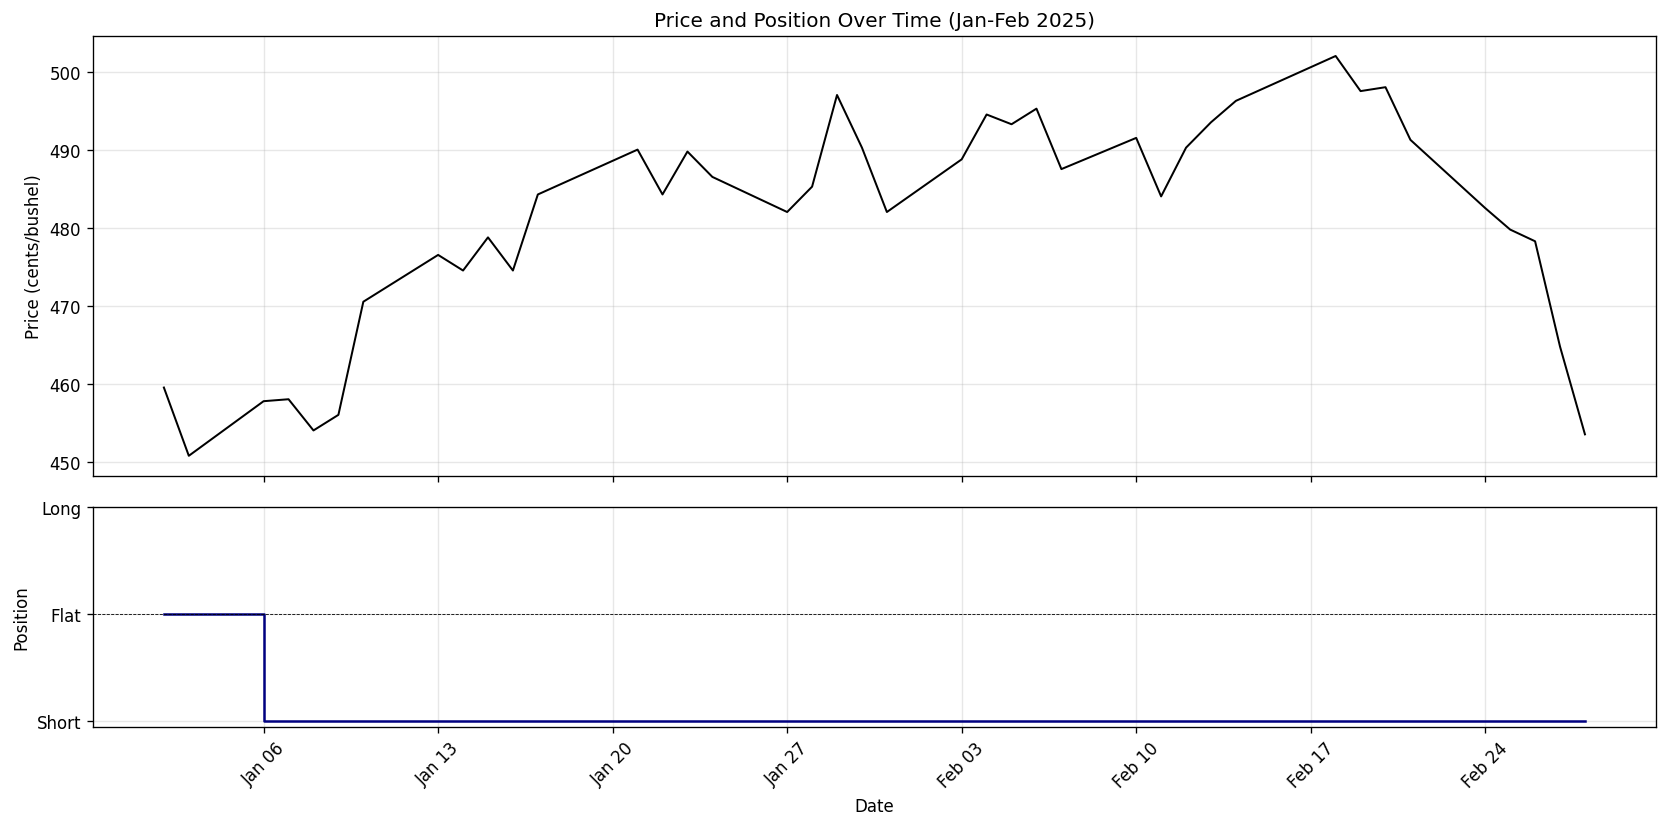

In [12]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 7),
    gridspec_kw={"height_ratios": [2, 1]}, sharex=True,
)

ax1.plot(df.index, df["Close"], linewidth=1.2, color="black")
ax1.set_ylabel("Price (cents/bushel)")
ax1.set_title("Price and Position Over Time (Jan-Feb 2025)")

ax2.step(df.index, df["position"], where="post", linewidth=1.5, color="navy")
ax2.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax2.set_ylabel("Position")
ax2.set_yticks([-1, 0, 1])
ax2.set_yticklabels(["Short", "Flat", "Long"])
ax2.set_xlabel("Date")
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
save_fig(fig, "04_position_over_time.png")
plt.show()

### Daily P&L

Bar chart of daily profit and loss in thousands of dollars. Green bars represent
profitable days; red bars represent losses.

2026-03-11 00:01:51,003 backtest_walkthrough INFO Saved figure: backtest_visuals/05_daily_pnl_bars.png


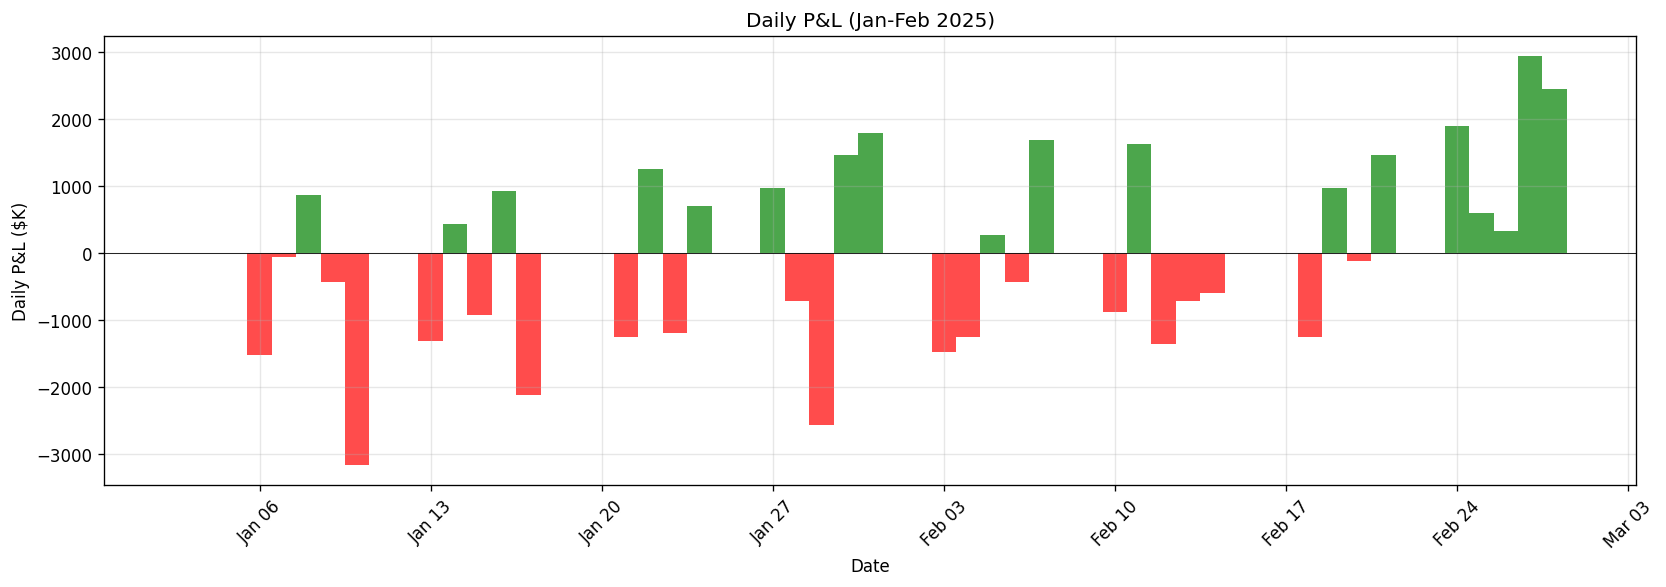

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["green" if v >= 0 else "red" for v in df["daily_pnl_usd"]]
ax.bar(df.index, df["daily_pnl_usd"] / 1e3, color=colors, alpha=0.7, width=1)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Daily P&L (Jan-Feb 2025)")
ax.set_ylabel("Daily P&L ($K)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
save_fig(fig, "05_daily_pnl_bars.png")
plt.show()

### Drawdown

The drawdown measures peak-to-trough decline in cumulative P&L. Shown here in
millions of dollars as a filled red area.

2026-03-11 00:01:51,233 backtest_walkthrough INFO Saved figure: backtest_visuals/06_drawdown.png


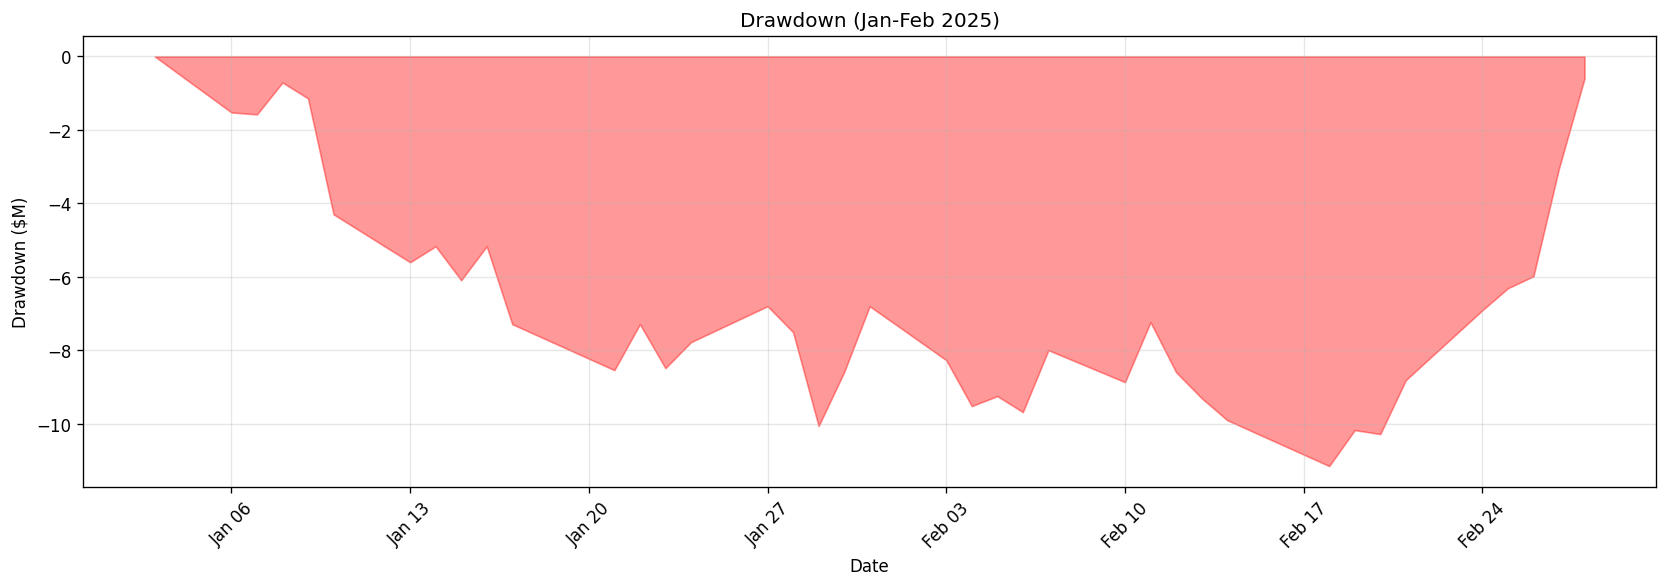

2026-03-11 00:01:51,309 backtest_walkthrough INFO Max drawdown: $-11.15M


In [14]:
running_max_usd = df["cumulative_pnl_usd"].cummax()
drawdown_usd = df["cumulative_pnl_usd"] - running_max_usd

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df.index, drawdown_usd / 1e6, 0, color="red", alpha=0.4)
ax.set_title("Drawdown (Jan-Feb 2025)")
ax.set_ylabel("Drawdown ($M)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
save_fig(fig, "06_drawdown.png")
plt.show()

logger.info("Max drawdown: $%.2fM", drawdown_usd.min() / 1e6)

### Rolling Precipitation and Signal

The top panel shows the 30-day rolling precipitation sum with the long and short
thresholds. The bottom panel shows the resulting signal as a step chart.

2026-03-11 00:01:51,483 backtest_walkthrough INFO Saved figure: backtest_visuals/07_precip_and_signal.png


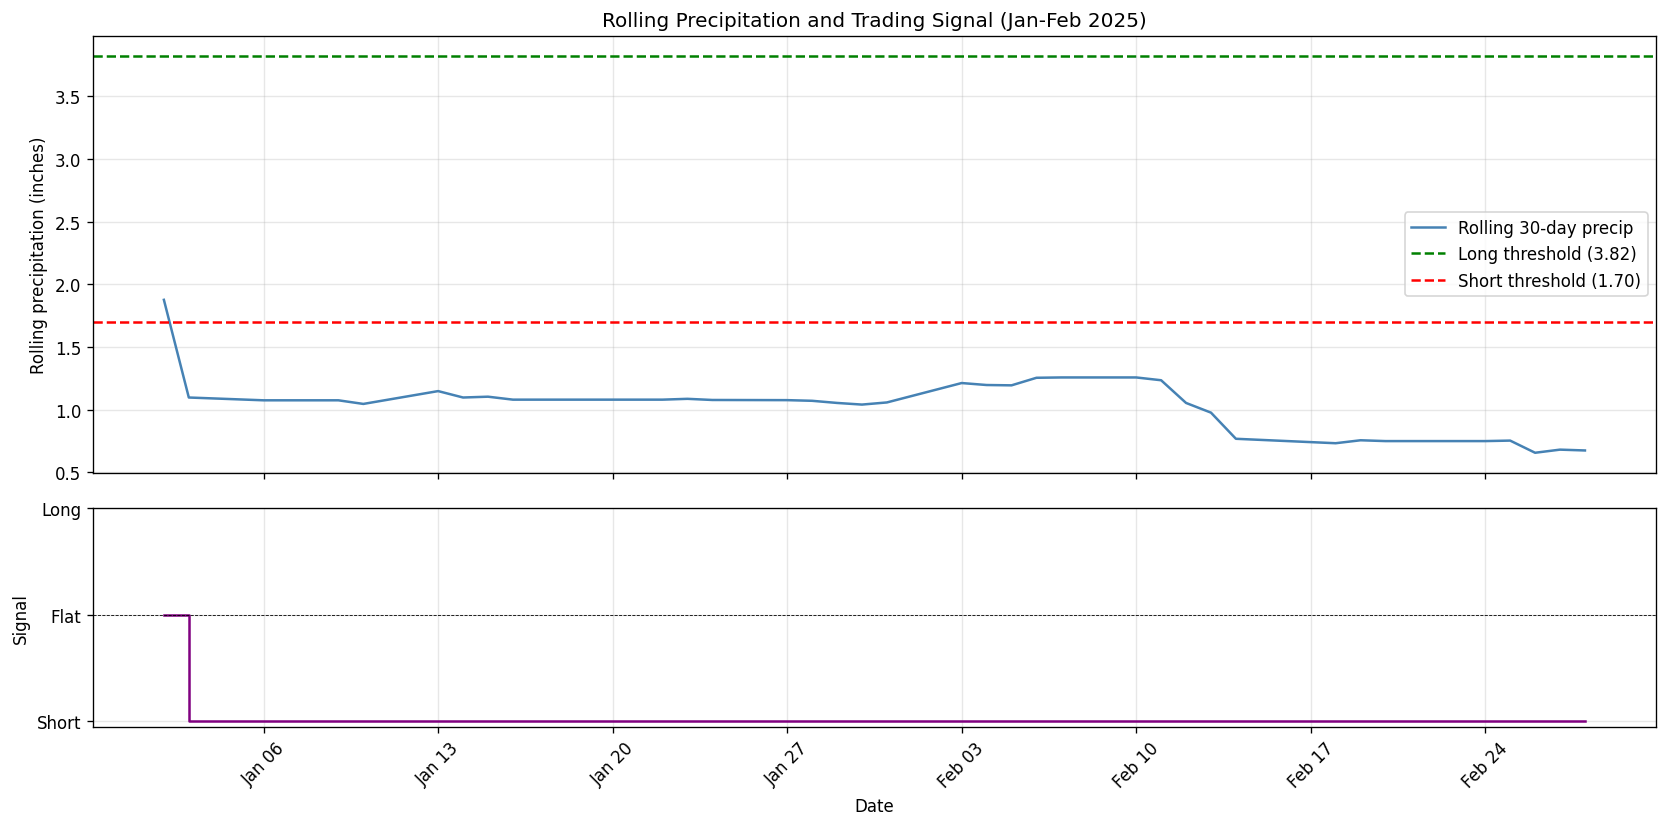

In [15]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 7),
    gridspec_kw={"height_ratios": [2, 1]}, sharex=True,
)

ax1.plot(
    df.index, df["rolling_precip"], linewidth=1.5, color="steelblue",
    label="Rolling 30-day precip",
)
ax1.axhline(
    threshold_long, color="green", linestyle="--",
    label=f"Long threshold ({threshold_long:.2f})",
)
ax1.axhline(
    threshold_short, color="red", linestyle="--",
    label=f"Short threshold ({threshold_short:.2f})",
)
ax1.set_ylabel("Rolling precipitation (inches)")
ax1.set_title("Rolling Precipitation and Trading Signal (Jan-Feb 2025)")
ax1.legend()

ax2.step(df.index, df["signal"], where="post", linewidth=1.5, color="purple")
ax2.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax2.set_ylabel("Signal")
ax2.set_yticks([-1, 0, 1])
ax2.set_yticklabels(["Short", "Flat", "Long"])
ax2.set_xlabel("Date")
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
save_fig(fig, "07_precip_and_signal.png")
plt.show()

## Part 8: Trade Log and Summary

### Trade Log

Each row represents a completed round-trip trade (entry to exit). The P&L is shown
in both cents/bushel and dollars.

In [16]:
trade_log = build_trade_log(df)

if len(trade_log) > 0:
    trade_log["pnl_usd"] = (
        trade_log["pnl"] * num_contracts * DOLLAR_PER_CENT_PER_CONTRACT
    )

trade_log

2026-03-11 00:01:51,635 backtest INFO Built trade log: 1 completed trades


,entry_date,exit_date,direction,entry_price,exit_price,pnl,holding_days,pnl_usd
0,2025-01-06,2025-02-28,short,457.75,453.5,4.25,53,924800.0


### Summary Statistics

Performance metrics for the Jan-Feb 2025 window. Dollar figures use the $100M
allocation (4,352 contracts). Cents/bushel figures are included at the bottom
for reference -- these are the per-unit price moves before scaling by position size.

In [17]:
stats = compute_stats(df, trade_log)

total_pnl_usd = stats["total_pnl"] * num_contracts * DOLLAR_PER_CENT_PER_CONTRACT
max_dd_usd = stats["max_drawdown"] * num_contracts * DOLLAR_PER_CENT_PER_CONTRACT
avg_win_usd = stats["avg_win"] * num_contracts * DOLLAR_PER_CENT_PER_CONTRACT
avg_loss_usd = stats["avg_loss"] * num_contracts * DOLLAR_PER_CENT_PER_CONTRACT

summary_rows = [
    ("Period", f"{df.index[0].date()} to {df.index[-1].date()}"),
    ("Trading Days", f"{len(df)}"),
    ("Allocation", f"${ALLOCATION_USD / 1e6:.0f}M"),
    ("Contracts", f"{num_contracts:,}"),
    ("", ""),
    ("Total P&L", f"${total_pnl_usd:,.0f}"),
    ("Max Drawdown", f"${max_dd_usd:,.0f}"),
    ("Sharpe Ratio (annualized)", f"{stats['sharpe_ratio']:.2f}"),
    ("", ""),
    ("Number of Trades", f"{stats['num_trades']}"),
    ("Win Rate", f"{stats['win_rate']:.1%}"),
    ("Avg Win (per trade)", f"${avg_win_usd:,.0f}"),
    ("Avg Loss (per trade)", f"${avg_loss_usd:,.0f}"),
    ("Avg Holding Period (days)", f"{stats['avg_holding_days']:.1f}"),
    ("", ""),
    ("Total P&L (cents/bushel)", f"{stats['total_pnl']:.2f}"),
    ("Max Drawdown (cents/bushel)", f"{stats['max_drawdown']:.2f}"),
]

summary_df = pd.DataFrame(summary_rows, columns=["Metric", "Value"])
summary_df

,Metric,Value
0,Period,2025-01-02 to 2025-02-28
1,Trading Days,40
2,Allocation,$100M
3,Contracts,"4,352"
4,,
5,Total P&L,"$-598,400"
6,Max Drawdown,"$-11,152,000"
7,Sharpe Ratio (annualized),-0.17
8,,
9,Number of Trades,1


## Observations

Key takeaways from this backtest window:

- The test period (Jan 2 -- Feb 28, 2025) covers approximately 40 trading days,
  which is a small sample size. Statistical significance of any results is limited.
- January and February are **off-season** for corn (planting runs Apr-Jun, harvest
  Sep-Nov). The precipitation-based signal is designed around growing-season dynamics
  and may behave differently outside that window.
- Contract count is fixed at entry, which avoids complexity but means position size
  does not adjust as prices move.

## Limitations

- **Short test window**: ~40 trading days is insufficient for robust conclusions.
  A multi-year out-of-sample test is needed.
- **No transaction costs**: Slippage, commissions, and bid-ask spread are ignored.
  These would reduce returns, especially for frequent position changes.
- **Off-season test**: The Jan-Feb window does not capture the growing season when
  precipitation most directly affects crop outcomes.
- **Single factor**: The signal uses only precipitation. Temperature extremes, soil
  moisture, USDA crop reports, and other fundamentals are omitted.
- **No position sizing**: The full allocation is deployed when the signal fires.
  Risk-based sizing (e.g., volatility targeting) would be more realistic.